# Replicating Tessler et al. (2024) Fig. 4C — minority weight in Habermas Machine group statements

Pipeline: Sentence-T5 embeddings → per-question position axis (negating → affirming) → position component scores →
convex regression of group-statement scores on constituent opinion scores, per level of division → minority weight
(sum of minority coefficients), averaged over levels.

Method (SM 5.1, 5.4.1): Sentence-T5 embeddings; per-question position axis = unit vector from the embedding of
"No, I disagree. <negating statement>" to "Yes, I agree. <affirming statement>"; position score = projection onto that axis;
minority = the side of neutral with fewer pre-deliberation ratings, neutral opinions count as non-minority; convex regression
(weights >= 0, sum = 1) of statement scores on the group's opinion scores, one regression per (group size, minority size) level,
minority weight = sum of minority coefficients, averaged over levels weighted by number of rounds.

This notebook is run once per embedding model. `HM_EMB_DIR` picks the cache; the results go to
`results/<model>/{fig4c_primary.json, sensitivity.csv, summary.json, blocked.json}`, which are the only results
the report reads. `python reproduce.py results` runs all four models and saves the executed
notebook beside them.

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from hm_fig4c import pipeline as P
from hm_fig4c.analysis import assign_minority
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

EMB_DIR = os.environ.get("HM_EMB_DIR", "../embeddings/st5-base")   # embedding cache to use
AXIS_METHOD = os.environ.get("HM_AXIS_METHOD", "unit")               # 'unit' (SM eq. 5: projection on the unit axis) or 'affine'
N_BOOT = int(os.environ.get("HM_N_BOOT", "500"))
MODEL_TAG = os.path.basename(EMB_DIR.rstrip("/"))
OUT_DIR = f"../results/{MODEL_TAG}"; os.makedirs(OUT_DIR, exist_ok=True)
print(EMB_DIR, AXIS_METHOD, N_BOOT)

../embeddings/st5-xl unit 500


## 1. Score all texts on the position axis

In [2]:
ENDPOINTS = os.environ.get("HM_ENDPOINTS", "prefixed")  # 'prefixed' (SM: generic + question-specific), 'plain', 'generic'
opinions, statements, questions, candidates = P.score_all("../prepared", EMB_DIR, method=AXIS_METHOD, endpoint_style=ENDPOINTS)
cov = pd.DataFrame({"opinions_scored": opinions.groupby("cohort")["score"].apply(lambda s: s.notna().mean()),
                    "initial_scored": statements.groupby("cohort")["initial_score"].apply(lambda s: s.notna().mean()),
                    "revised_scored": statements.groupby("cohort")["revised_score"].apply(lambda s: s.notna().mean()),
                    "candidates_scored": candidates.groupby("cohort")["score"].apply(lambda s: s.notna().mean()),
                    "n_rounds": statements.groupby("cohort").size(), "n_prereg_rounds": statements.groupby("cohort")["prereg"].sum()})
cov.round(3)

,opinions_scored,initial_scored,revised_scored,candidates_scored,n_rounds,n_prereg_rounds
cohort,,,,,,
cohort1,0.634,0.591,0.591,0.596,508,300
cohort2,0.821,0.760,0.760,0.767,592,450
cohort3,0.819,0.758,0.758,0.759,392,297
cohort4,0.602,0.538,0.538,0.175,279,150
training,0.000,0.000,0.000,0.000,1688,0
vca,0.000,0.000,0.000,0.000,323,0


Each opinion now carries a `score`: the projection of its embedding on its question's position axis.

In [3]:
opinions[["metadata.version", "launch_id", "round_id", "participant_id", "pre_rating", "score", "opinion_text"]].head()

,metadata.version,launch_id,round_id,participant_id,pre_rating,score,opinion_text
0,TRAINING_DATA_V1,17b6daea928a41c6a5727aa0c5d674b9,315be495e0403a1570c0d3ed7ae548b9,35a875f9b5,2.0,NaN,I dont think parents should be able to opt out...
1,TRAINING_DATA_V1,17b6daea928a41c6a5727aa0c5d674b9,315be495e0403a1570c0d3ed7ae548b9,196beeb338,2.0,NaN,I don't believe they should be allowed to opt ...
2,TRAINING_DATA_V1,17b6daea928a41c6a5727aa0c5d674b9,315be495e0403a1570c0d3ed7ae548b9,6036bc29ed,2.0,NaN,I think sex education should be somewhat manda...
3,TRAINING_DATA_V1,17b6daea928a41c6a5727aa0c5d674b9,315be495e0403a1570c0d3ed7ae548b9,49d58e7851,2.0,NaN,In my opinion I feel like every child should l...
4,TRAINING_DATA_V1,17b6daea928a41c6a5727aa0c5d674b9,315be495e0403a1570c0d3ed7ae548b9,b650c3ef1c,2.0,NaN,"On the whole, I don't they they should. It is ..."


The candidate statements are scored on the same axis, one row per candidate the mediator produced.

In [4]:
candidates[["launch_id", "round_id", "phase", "is_winner", "score", "candidate_text"]].head()

,launch_id,round_id,phase,is_winner,score,candidate_text
0,17b6daea928a41c6a5727aa0c5d674b9,315be495e0403a1570c0d3ed7ae548b9,initial,False,NaN,"In general, the citizen's jury felt that the c..."
1,17b6daea928a41c6a5727aa0c5d674b9,315be495e0403a1570c0d3ed7ae548b9,initial,False,NaN,Citizen's Jury
2,17b6daea928a41c6a5727aa0c5d674b9,315be495e0403a1570c0d3ed7ae548b9,initial,False,NaN,Children should receive sex education in schoo...
3,17b6daea928a41c6a5727aa0c5d674b9,315be495e0403a1570c0d3ed7ae548b9,initial,True,NaN,"Sex education is very important in schools, as..."
4,17b6daea928a41c6a5727aa0c5d674b9,315be495e0403a1570c0d3ed7ae548b9,revised,False,NaN,"Sex education is very important in schools, as..."


## 2. Fig. 4A check — opinion position score vs pre-deliberation position rating (paper: r = 0.64)

In [5]:
rows = {c: P.fig4a_correlation(P.select_cohort(opinions, c)) for c in ["cohort1", "cohort2", "cohort3", "cohorts_1_3", "cohort4", "training", "vca"]}
fig4a = pd.DataFrame(rows).T; fig4a

,r,r2,n
cohort1,0.652027,0.425140,1430.0
cohort2,0.663874,0.440728,2136.0
cohort3,0.691944,0.478787,1413.0
cohorts_1_3,0.669464,0.448182,4979.0
cohort4,0.668010,0.446237,729.0
training,NaN,NaN,0.0
vca,NaN,NaN,0.0


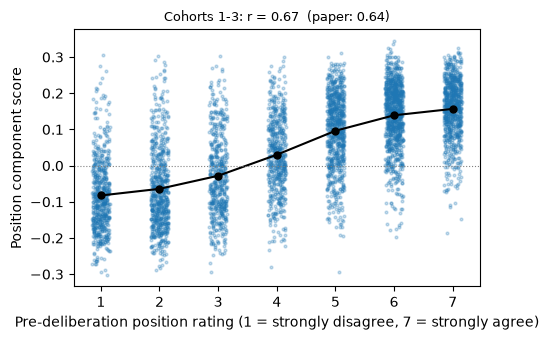

In [6]:
d = P.select_cohort(opinions, "cohorts_1_3").dropna(subset=["score", "pre_rating"])
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.scatter(d["pre_rating"] + np.random.uniform(-.15, .15, len(d)), d["score"], s=4, alpha=.25)
means = d.groupby("pre_rating")["score"].mean()
ax.plot(means.index, means.values, "o-", color="k", ms=5)
ax.set_xlabel("Pre-deliberation position rating (1 = strongly disagree, 7 = strongly agree)"); ax.set_ylabel("Position component score")
ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.set_title(f"Cohorts 1-3: r = {fig4a.loc['cohorts_1_3','r']:.2f}  (paper: 0.64)", fontsize=9); plt.tight_layout()

## 3. Fig. 4B check — statement scores relative to the group's opinions (paper: 96% within range)

In [7]:
fig4b = {c: P.fig4b_within_range(P.select_cohort(opinions, c), P.select_cohort(statements, c)) for c in ["cohorts_1_3", "training", "vca"]}
pd.DataFrame({(c, s): v for c, dd in fig4b.items() for s, v in dd.items()}).T

/private/tmp/claude-501/-Users-daxmavy/b0ee5172-0e93-415f-9966-9bb29d5fb5d7/scratchpad/habermas-replication/hm_fig4c/pipeline.py:87: RuntimeWarning: invalid value encountered in scalar divide
  out["both"] = {"within": float((((both["initial_score"] >= both["min"]) & (both["initial_score"] <= both["max"])).sum() +
/private/tmp/claude-501/-Users-daxmavy/b0ee5172-0e93-415f-9966-9bb29d5fb5d7/scratchpad/habermas-replication/hm_fig4c/pipeline.py:87: RuntimeWarning: invalid value encountered in scalar divide
  out["both"] = {"within": float((((both["initial_score"] >= both["min"]) & (both["initial_score"] <= both["max"])).sum() +


within       n
cohorts_1_3 initial_score  0.843362  1047.0
            revised_score  0.875836  1047.0
            both           0.859599  2094.0
training    initial_score       NaN     0.0
            revised_score       NaN     0.0
            both                NaN     0.0
vca         initial_score       NaN     0.0
            revised_score       NaN     0.0
            both                NaN     0.0

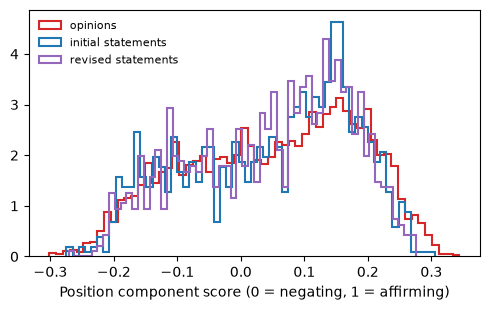

In [8]:
d_op = P.select_cohort(opinions, "cohorts_1_3"); d_st = P.select_cohort(statements, "cohorts_1_3")
fig, ax = plt.subplots(figsize=(5, 3.2))
for vals, lab, col in [(d_op["score"], "opinions", "tab:red"), (d_st["initial_score"], "initial statements", "tab:blue"), (d_st["revised_score"], "revised statements", "tab:purple")]:
    ax.hist(vals.dropna(), bins=60, density=True, histtype="step", lw=1.5, label=lab, color=col)
ax.set_xlabel("Position component score (0 = negating, 1 = affirming)"); ax.legend(frameon=False, fontsize=8); plt.tight_layout()

## 4. Fig. 4C — minority weight via convex regression (primary specification)

Main-task cohorts 1–3, pre-registered groups (n = 1047 rounds); minority = smaller side of neutral on the pre-deliberation
rating, neutral opinions kept as non-minority (SM 5.4.1); columns ordered as in the data.
A round whose two sides are equal keeps its majority direction rather than being dropped: SM 4.1.2.1 sets that direction
to AGREE, so the disagree side is the minority. Rounds with no dissent at all have no minority and drop out.
Analytic SEs are the OLS standard errors of the constrained fit (as in the paper); bootstrap SEs resample rounds.

`assign_minority` is the rule in one place: `side` is the sign of `pre_rating - 4`, `k_min` the
size of the smaller side, `n_div` the group size, and `is_minority` marks the opinions whose weights
are summed. Only rounds with no dissent drop out here; a tied round is resolved, not dropped.

In [9]:
op_div = assign_minority(P.select_cohort(opinions, "cohorts_1_3"), neutral="as_majority", ties="majority_agree", by="rating")
op_div[["launch_id", "round_id", "participant_id", "pre_rating", "side", "is_minority", "k_min", "n_div", "score"]].head()

,launch_id,round_id,participant_id,pre_rating,side,is_minority,k_min,n_div,score
7164,283280b320114e0a98aa1d59805e2d80,d29f9ac3acfa3db5d9425c42c7c960a2,24ab70e805,2.0,-1,False,1,5,0.263659
7165,283280b320114e0a98aa1d59805e2d80,d29f9ac3acfa3db5d9425c42c7c960a2,47df8e9bd7,3.0,-1,False,1,5,0.062225
7166,283280b320114e0a98aa1d59805e2d80,d29f9ac3acfa3db5d9425c42c7c960a2,eaf0961969,2.0,-1,False,1,5,0.132704
7167,283280b320114e0a98aa1d59805e2d80,d29f9ac3acfa3db5d9425c42c7c960a2,f01f5fd045,6.0,1,True,1,5,0.098958
7168,283280b320114e0a98aa1d59805e2d80,d29f9ac3acfa3db5d9425c42c7c960a2,ed0d346eb4,3.0,-1,False,1,5,0.056138


In [10]:
op_div.groupby(["n_div", "k_min"])["launch_id"].size().rename("opinions").to_frame().T

n_div     3    4          5     
k_min     1    1    2     1    2
opinions  6  452  136  1565  985

In [11]:
res = P.run_minority_analysis(opinions, candidates, cohort="cohorts_1_3", neutral="as_majority", order="data", n_boot=N_BOOT)
P.save_results(res, f"{OUT_DIR}/fig4c_primary.json")
summary = P.summarize(res); summary.round(3)

,phase,minority_weight,se,boot_se,true_share,t_vs_true,n_targets,n_rounds
0,opinions,0.283,0.000,NaN,0.283,NaN,3138,NaN
1,initial_candidates,0.234,0.013,0.016,0.284,-3.986,2628,659.0
2,initial_winner,0.162,0.017,0.017,0.284,-7.343,657,659.0
3,revised_candidates,0.207,0.009,0.014,0.284,-8.805,2628,659.0
4,revised_winner,0.193,0.015,0.015,0.284,-5.902,657,659.0


In [12]:
pd.DataFrame(res["contrasts"]).T.round(3)

,diff,boot_se,boot_ci95,boot_p_le_0
revised_winner - initial_winner,0.030757,0.010282,"[0.010351818283484745, 0.050189317486848836]",0.004
revised_candidates - initial_candidates,-0.026767,0.015036,"[-0.055573212557584524, 0.0026712948402188275]",0.958
revised_winner - initial_candidates,-0.040791,0.016476,"[-0.07228193109082139, -0.009968378134374551]",0.996


One convex regression per level of division; the aggregate above averages these, weighted by rounds.

In [13]:
P.per_level_table(res).round(3)

minority_weight                                                                  se                                                            n_rounds                 \
phase          initial_candidates initial_winner revised_candidates revised_winner initial_candidates initial_winner revised_candidates revised_winner initial_candidates initial_winner   
n k true_share                                                                                                                                                                             
4 1 0.25                    0.219          0.120              0.175          0.132              0.031          0.042              0.022          0.038              452.0          113.0   
  2 0.50                    0.546          0.533              0.502          0.560              0.064          0.079              0.042          0.077              136.0           34.0   
5 1 0.20                    0.142          0.077              0.122          0.103              0.017          0.022              0.012          0.021             1252.0          313.0   
  2 0.40                    0.335          0.258              0.310          0.308              0.024          0.032              0.017          0.031              788.0          197.0   

                                                  
phase          revised_candidates revised_winner  
n k true_share                                    
4 1 0.25                    452.0          113.0  
  2 0.50                    136.0           34.0  
5 1 0.20                   1252.0          313.0  
  2 0.40                    788.0          197.0

## 5. Sensitivity analyses
Every combination of the choices the SM leaves open (`P.sensitivity_grid()`): neutral-opinion treatment × basis for the
minority split × tie rule × column order of the design matrix; model size is swept by running this notebook once per
embedding model. The sample (pre-registered rounds of cohorts 1–3) is the one SM 4.4 describes and is not varied.

In [14]:
sens = P.run_sensitivity(opinions, candidates, P.sensitivity_grid())
sens.to_csv(f"{OUT_DIR}/sensitivity.csv", index=False); sens.round(3)

,variant,minority_by,neutral,ties,order,n_rounds,true_share,initial_candidates,initial_candidates_se,initial_winner,initial_winner_se,revised_candidates,revised_candidates_se,revised_winner,revised_winner_se
0,split=Likert rating | neutral=non-minority | t...,rating,as_majority,majority_agree,data,659,0.284,0.234,0.013,0.162,0.017,0.207,0.009,0.193,0.015
1,split=Likert rating | neutral=non-minority | t...,rating,as_majority,majority_agree,random,659,0.284,0.234,0.013,0.166,0.017,0.207,0.009,0.192,0.015
2,split=Likert rating | neutral=non-minority | t...,rating,as_majority,majority_disagree,data,659,0.284,0.222,0.012,0.158,0.016,0.209,0.009,0.188,0.015
3,split=Likert rating | neutral=non-minority | t...,rating,as_majority,majority_disagree,random,659,0.284,0.223,0.012,0.159,0.017,0.208,0.009,0.187,0.015
4,split=Likert rating | neutral=non-minority | t...,rating,as_majority,exclude,data,560,0.262,0.200,0.013,0.123,0.017,0.178,0.009,0.157,0.016
5,split=Likert rating | neutral=non-minority | t...,rating,as_majority,exclude,random,560,0.262,0.201,0.013,0.128,0.017,0.180,0.009,0.158,0.016
6,split=Likert rating | neutral=opinion dropped ...,rating,drop_participant,majority_agree,data,659,0.321,0.280,0.012,0.214,0.016,0.255,0.008,0.243,0.015
7,split=Likert rating | neutral=opinion dropped ...,rating,drop_participant,majority_agree,random,659,0.321,0.276,0.012,0.212,0.016,0.252,0.008,0.241,0.015
8,split=Likert rating | neutral=opinion dropped ...,rating,drop_participant,majority_disagree,data,659,0.321,0.261,0.012,0.204,0.016,0.254,0.008,0.234,0.015
9,split=Likert rating | neutral=opinion dropped ...,rating,drop_participant,majority_disagree,random,659,0.321,0.261,0.012,0.201,0.016,0.249,0.008,0.230,0.015


## 6. An alternative specification of the convex regression

The regression above fits one coefficient per column of the design matrix, and column $j$ pools "the
$j$-th opinion" across rounds -- different people in different rounds -- so the fit depends on how a
round's opinions are assigned to columns, which the SM never specifies. Restricting the model so that
every minority opinion carries the same weight $a/k$ and every non-minority opinion the same weight
$(1-a)/(n-k)$ removes that choice. The prediction then collapses to two columns, the two block means:

$$y_i \;=\; a\,\bar{x}^{\,\text{min}}_i \;+\; (1-a)\,\bar{x}^{\,\text{non}}_i,
\qquad 0 \le a \le 1 .$$

The $k$ minority opinions each carry $a/k$, so $a$ *is* the summed minority weight: the same estimand
as above under an added exchangeability assumption within each block, not a different quantity.
`build_design(columns="blocks")` builds this design; the levels, the `min_rounds` filter, the
round weighting and the cluster bootstrap are unchanged, so the two fits run on identical samples.

In [15]:
blocked = P.run_minority_analysis(opinions, candidates, cohort="cohorts_1_3", neutral="as_majority", order="data",
                                  n_boot=N_BOOT, columns="blocks")
per_opinion, per_block = P.summarize(res).set_index("phase"), P.summarize(blocked).set_index("phase")
compare = pd.DataFrame({"per-opinion weight": per_opinion["minority_weight"], "per-opinion boot SE": per_opinion["boot_se"],
                        "blocked weight": per_block["minority_weight"], "blocked boot SE": per_block["boot_se"],
                        "true_share": per_block["true_share"], "n_targets": per_block["n_targets"], "n_rounds": per_block["n_rounds"]})
compare.round(3)

,per-opinion weight,per-opinion boot SE,blocked weight,blocked boot SE,true_share,n_targets,n_rounds
phase,,,,,,,
opinions,0.283,NaN,0.283,NaN,0.283,3138,NaN
initial_candidates,0.234,0.016,0.233,0.015,0.284,2628,659.0
initial_winner,0.162,0.017,0.164,0.017,0.284,657,659.0
revised_candidates,0.207,0.014,0.207,0.014,0.284,2628,659.0
revised_winner,0.193,0.015,0.194,0.015,0.284,657,659.0


The blocked fit cannot depend on the column order, because a block mean does not. Running both
designs under both orders of `P.sensitivity_grid()` shows it: the blocked runs agree exactly, the
per-opinion runs do not.

In [16]:
order_runs = {(cols, order): P.run_minority_analysis(opinions, candidates, order=order, columns=cols)
              for cols in ["blocks", "per_opinion"] for order in ["data", "random"]}
order_table = pd.DataFrame({f"{cols} | {order}": {phase: r["phases"][phase]["weight"] for phase in ["opinions"] + P.PHASES}
                            for (cols, order), r in order_runs.items()})
order_diff = {cols: float(max(abs(order_runs[(cols, "data")]["phases"][phase]["weight"] - order_runs[(cols, "random")]["phases"][phase]["weight"])
                              for phase in ["opinions"] + P.PHASES)) for cols in ["blocks", "per_opinion"]}
print("max |data order - random order| :", order_diff)
assert order_diff["blocks"] == 0.0, order_diff
order_table.round(4)

max |data order - random order| : {'blocks': 0.0, 'per_opinion': 0.0036028005423576204}


,blocks | data,blocks | random,per_opinion | data,per_opinion | random
opinions,0.2830,0.2830,0.2830,0.2830
initial_candidates,0.2331,0.2331,0.2339,0.2339
initial_winner,0.1642,0.1642,0.1624,0.1660
revised_candidates,0.2070,0.2070,0.2071,0.2069
revised_winner,0.1938,0.1938,0.1931,0.1917


`blocked.json` is the fourth file the report reads: the blocked weight, its bootstrap standard
error, the true share and the rounds behind it at each phase and at the sanity check, together with
the two order runs under each design.

In [17]:
BLOCKED = {"columns": "blocks", "n_boot": N_BOOT, "order_max_abs_diff": order_diff, "phases": {}}
for phase in ["opinions"] + P.PHASES:
    e = blocked["phases"][phase]
    BLOCKED["phases"][phase] = {"weight": e["weight"], "boot_se": e.get("boot_se"), "true_share": e["true_share"],
                                "n_targets": e["n_targets"], "n_rounds": e.get("n_rounds"),
                                "per_opinion_weight": res["phases"][phase]["weight"],
                                "order_data": order_runs[("blocks", "data")]["phases"][phase]["weight"],
                                "order_random": order_runs[("blocks", "random")]["phases"][phase]["weight"],
                                "per_opinion_order_data": order_runs[("per_opinion", "data")]["phases"][phase]["weight"],
                                "per_opinion_order_random": order_runs[("per_opinion", "random")]["phases"][phase]["weight"]}
json.dump(BLOCKED, open(f"{OUT_DIR}/blocked.json", "w"), indent=1, default=float)
print("wrote", f"{OUT_DIR}/blocked.json")
pd.DataFrame(BLOCKED["phases"]).T.round(4)

wrote ../results/st5-xl/blocked.json


,weight,boot_se,true_share,n_targets,n_rounds,per_opinion_weight,order_data,order_random,per_opinion_order_data,per_opinion_order_random
opinions,0.2830,NaN,0.2830,3138.0,NaN,0.2830,0.2830,0.2830,0.2830,0.2830
initial_candidates,0.2331,0.0154,0.2841,2628.0,659.0,0.2339,0.2331,0.2331,0.2339,0.2339
initial_winner,0.1642,0.0173,0.2841,657.0,659.0,0.1624,0.1642,0.1642,0.1624,0.1660
revised_candidates,0.2070,0.0143,0.2841,2628.0,659.0,0.2071,0.2070,0.2070,0.2071,0.2069
revised_winner,0.1938,0.0150,0.2841,657.0,659.0,0.1931,0.1938,0.1938,0.1931,0.1917


## 7. Summary vs paper

The paper's own numbers, read off the position-embedding panel of SM Fig. S60 (the expanded
version of main-text Fig. 4C, per SM 5.2.2), plus the two axis checks it reports. They are literals:
nothing in this repository can recompute them.

In [18]:
# Paper's values: SM Fig. S60, position-embedding panel (fig4a_r: main-text Fig. 4A; fig4b_within: main-text Fig. 4B).
paper = {"n_rounds": 1047, "minority_share": 0.285, "opinions_sanity": 0.28, "initial_candidates": 0.28, "initial_winner": 0.29,
         "revised_candidates": 0.33, "revised_winner": 0.36, "revised_winner_se": 0.03, "revised_winner_t_vs_true": 2.64,
         "fig4a_r": 0.64, "fig4b_within": 0.96}

In [19]:
ph = res["phases"]
ours = {"n_rounds": ph["initial_winner"]["n_rounds"], "n_rounds_total": int(P.select_cohort(statements, "cohorts_1_3")["initial_id"].notna().sum()),
        "minority_share": ph["initial_winner"]["true_share"], "opinions_sanity": ph["opinions"]["weight"],
        **{p: ph[p]["weight"] for p in P.PHASES}, "revised_winner_se": ph["revised_winner"]["se"], "revised_winner_t_vs_true": ph["revised_winner"]["t_vs_true"],
        "fig4a_r": fig4a.loc["cohorts_1_3", "r"], "fig4b_within": fig4b["cohorts_1_3"]["both"]["within"], "model": MODEL_TAG, "endpoints": ENDPOINTS, "axis": AXIS_METHOD}
json.dump({"paper": paper, "ours": ours}, open(f"{OUT_DIR}/summary.json", "w"), indent=1, default=float)
pd.DataFrame({"paper": paper, "ours": ours}).round(3)

,paper,ours
n_rounds,1047.000,659
minority_share,0.285,0.284094
opinions_sanity,0.280,0.282983
initial_candidates,0.280,0.23391
initial_winner,0.290,0.162362
revised_candidates,0.330,0.207142
revised_winner,0.360,0.193118
revised_winner_se,0.030,0.015415
revised_winner_t_vs_true,2.640,-5.901896
fig4a_r,0.640,0.669464
